# B-4064A — Anomalias per-sensor LSTM (seq_len=24) | Treino: até Jun/2024

Carrega artifacts per-sensor da task ClearML de LSTM e plota por sensor.

- Um modelo por sensor, janela temporal de 24h
- Comparação com baseline multivariado (Dense) para referência
- Score atribuído ao último timestamp da janela → primeiros 23h sem score


In [5]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing


In [6]:
# ==============================
# Configuracao
# ==============================
PER_SENSOR_TASK_ID  = '11533ad3c96249a9aca4465cdf7c7d36'  # LSTM per-sensor seq_len=24 moving_average
MULTIVARIATE_TASK_ID = 'eda0e53c09464587b9f3fc11cf99cba8'  # LSTM multivariado (comparacao)
EQUIPMENT_ID = 'B-4064A-novos'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1  = '2024-08-30 07:58'
EVENT_LABEL_F1 = 'Inicio restricao (30/Ago/2024)'
EVENT_DATE_F2  = '2025-04-07'
EVENT_LABEL_F2 = 'Inicio restricao (07/Abr/2025)'

EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
EVENT_TS_F2 = pd.Timestamp(EVENT_DATE_F2)

WINDOW_F1_ZOOM_START  = EVENT_TS_F1 - pd.Timedelta(days=10)
WINDOW_F1_ZOOM_END    = EVENT_TS_F1
WINDOW_2025_START     = '2025-01-01'
WINDOW_2025_END       = '2025-12-31'
WINDOW_F2_ZOOM_START  = EVENT_TS_F2 - pd.Timedelta(days=10)
WINDOW_F2_ZOOM_END    = EVENT_TS_F2

SENSITIVITY_PRESET  = 'conservative'
CALIB_START = '2025-05-01'
CALIB_END   = '2025-12-31'
CALIB_PERCENTILES       = [99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID  = [(3, 5), (4, 6), (5, 8)]
TARGET_ALERTS_PER_DAY   = 0.5

PLOT_MODE               = 'separated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'
SAVE_PLOTS = False
OUTPUT_DPI    = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT  = 2.5


In [7]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')
    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')
    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_per_sensor_task_outputs(task_id: str, use_full_scores: bool = True):
    """Carrega todos os artifacts per-sensor de uma task ClearML."""
    task = Task.get_task(task_id=task_id)
    artifacts = task.artifacts

    # Descobre slugs disponíveis via artifacts de scores
    score_prefix = 'full_scores__' if use_full_scores else 'test_scores__'
    fallback_prefix = 'test_scores__'

    slugs = []
    for name in artifacts:
        if name.startswith('full_scores__') or name.startswith('test_scores__'):
            slug = name.split('__', 1)[1]
            if slug not in slugs:
                slugs.append(slug)

    entries = {}
    for slug in slugs:
        score_name = f'full_scores__{slug}' if (use_full_scores and f'full_scores__{slug}' in artifacts) else f'test_scores__{slug}'
        results_name = f'results__{slug}'

        scores = _normalize_scores_df(artifacts[score_name].get())
        results = artifacts[results_name].get() if results_name in artifacts else {}
        threshold = float(results.get('threshold', float('nan')))
        sensor = results.get('sensor', slug)

        entries[slug] = {'sensor': sensor, 'scores': scores, 'threshold': threshold, 'results': results}

    summary = artifacts['per_sensor_summary'].get() if 'per_sensor_summary' in artifacts else None
    return task, entries, summary


def load_task_outputs(task_id: str, use_full_scores: bool = True):
    task = Task.get_task(task_id=task_id)
    results = task.artifacts['results'].get()
    threshold = float(results['threshold'])
    score_name = 'full_scores' if (use_full_scores and 'full_scores' in task.artifacts) else 'test_scores'
    scores = _normalize_scores_df(task.artifacts[score_name].get())
    return task, results, threshold, scores, score_name


def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)
    pre_steps = config.pre_split_steps
    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw
    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config


def slice_window(df_base, scores, window_start, window_end):
    dfw = df_base.loc[pd.Timestamp(window_start):pd.Timestamp(window_end)].copy()
    sw  = scores.loc[pd.Timestamp(window_start):pd.Timestamp(window_end)].copy()
    common = dfw.index.intersection(sw.index)
    if len(common) == 0:
        raise ValueError(f'sem intersecao na janela {window_start}..{window_end}')
    return dfw.loc[common], sw.loc[common]


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores, calib_start, calib_end):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')
    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({'percentile': p, 'threshold': thr, 'k': k, 'n': n,
                          'alerts_per_day': alerts_per_day,
                          'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY)})
    df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = df.iloc[0]
    return {'threshold': float(best['threshold']), 'k': int(best['k']),
            'n': int(best['n']), 'percentile': float(best['percentile']),
            'alerts_per_day': float(best['alerts_per_day']), 'table': df}


Task per-sensor: 11533ad3c96249a9aca4465cdf7c7d36
Sensores encontrados: 8

Summary:


,sensor,sensor_slug,threshold,train_mse_mean,test_mse_mean,n_anomalies,n_test_samples
0,Corrente,corrente,0.078428,0.026273,0.022074,287,7689
1,Pressão Descarga,press_o_descarga,0.261081,0.070050,0.069119,519,11465
2,Pressão Sucção,press_o_suc_o,0.145349,0.045954,0.155588,3498,13990
3,Temperatura Bomba LA,temperatura_bomba_la,0.021278,0.006129,0.005923,530,13991
4,Temperatura Bomba LNA,temperatura_bomba_lna,0.074985,0.024404,0.048117,2261,13990
5,Temperatura Motor LA,temperatura_motor_la,0.218627,0.059153,0.051392,442,13992
6,Temperatura Motor LNA,temperatura_motor_lna,0.180229,0.050708,0.048585,671,13992
7,Vibração Bomba LNA,vibra_o_bomba_lna,0.094026,0.029936,0.024580,601,13990



Sensibilidade calibrada (baseada em corrente): k=3, n=5, p=99.0

Sensor: Corrente | threshold=0.078428


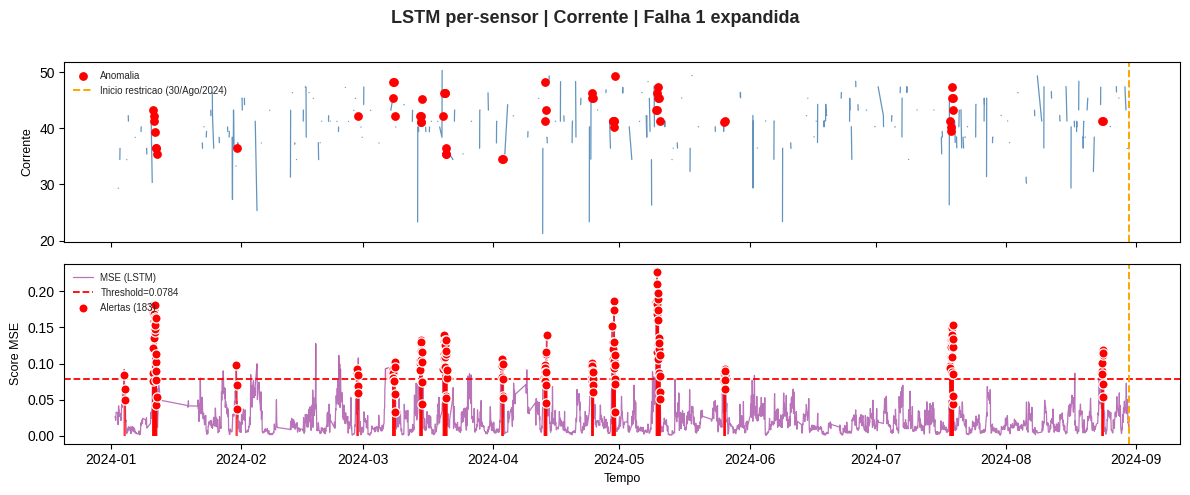

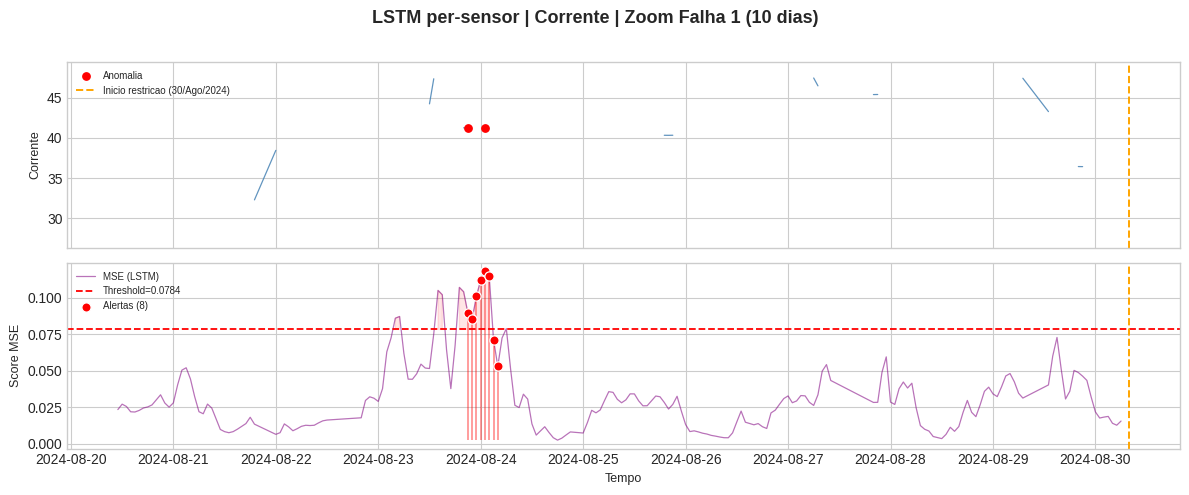

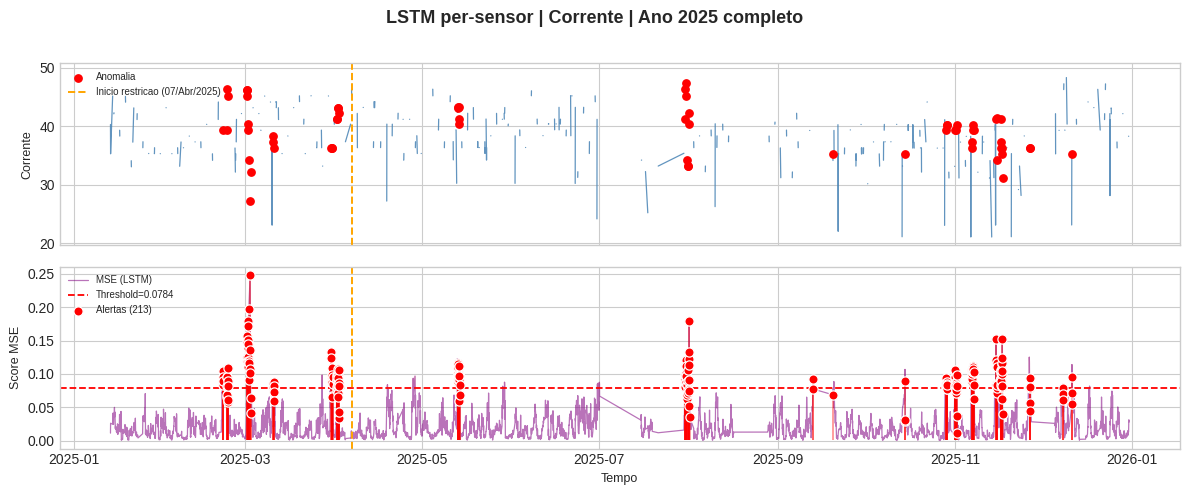

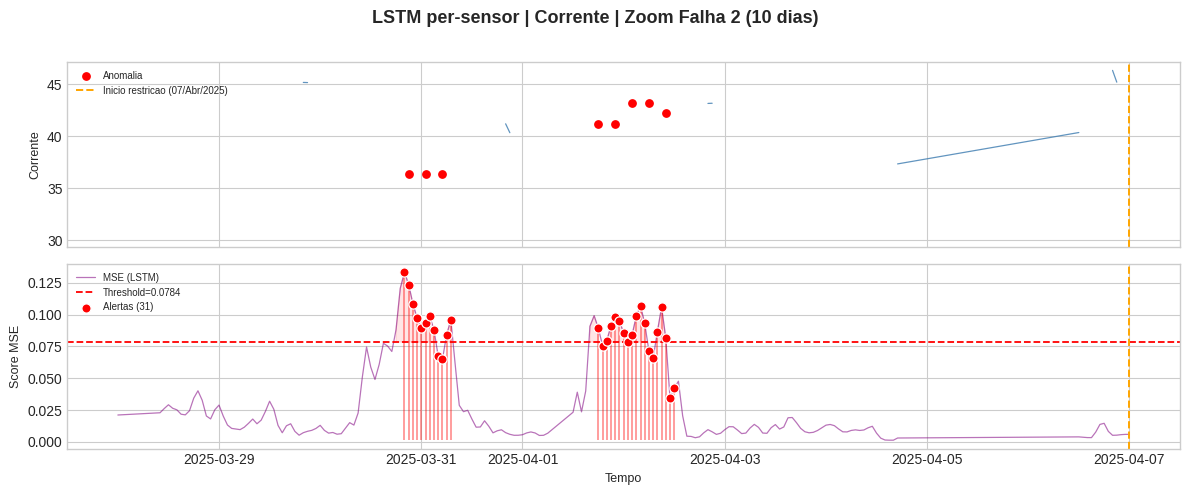


Sensor: Pressão Descarga | threshold=0.261081


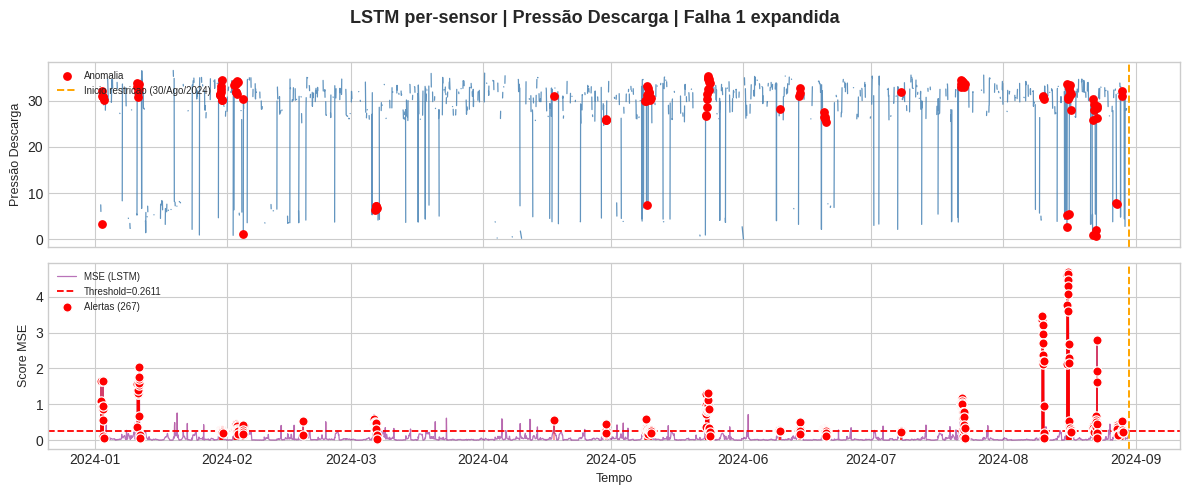

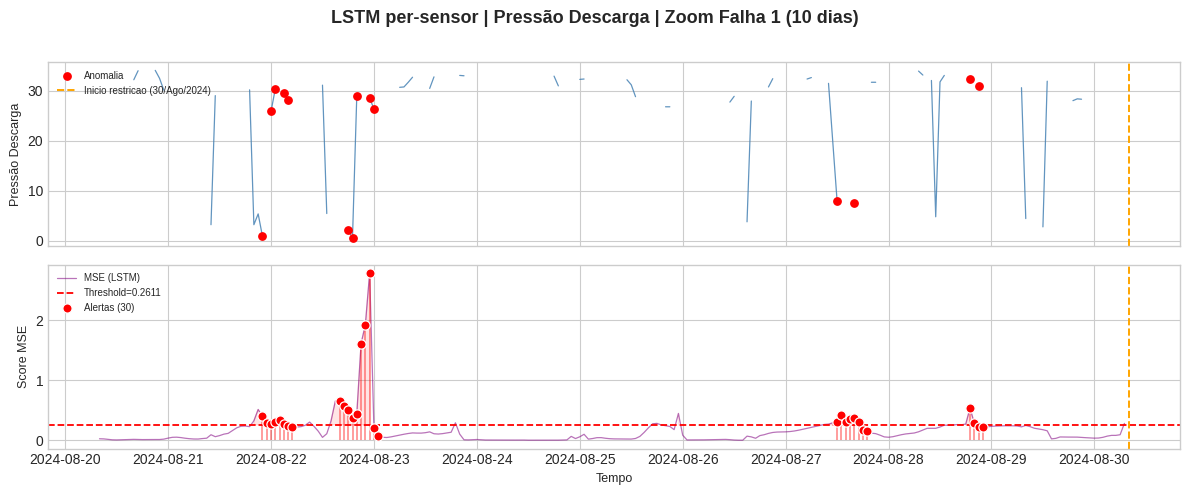

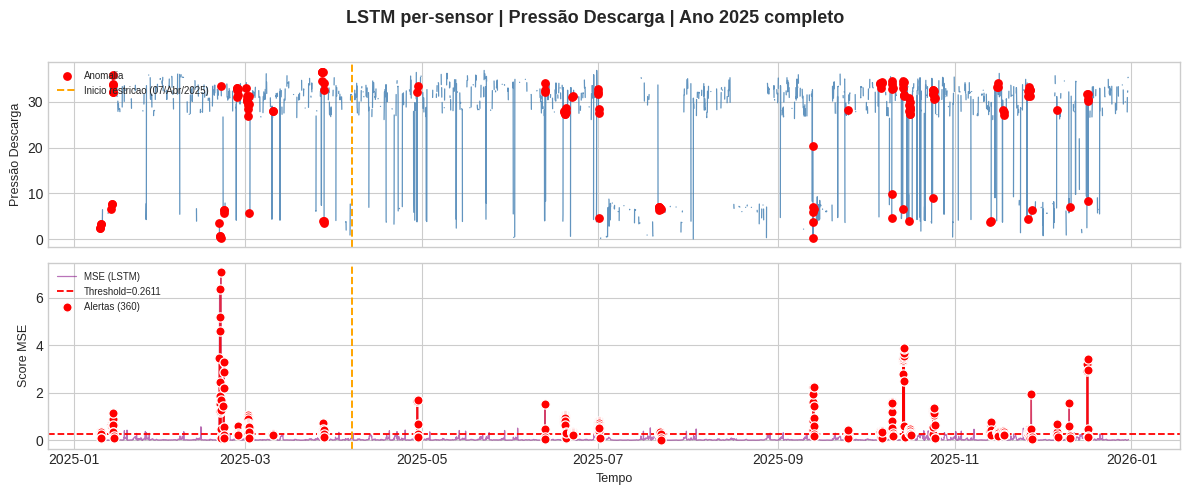

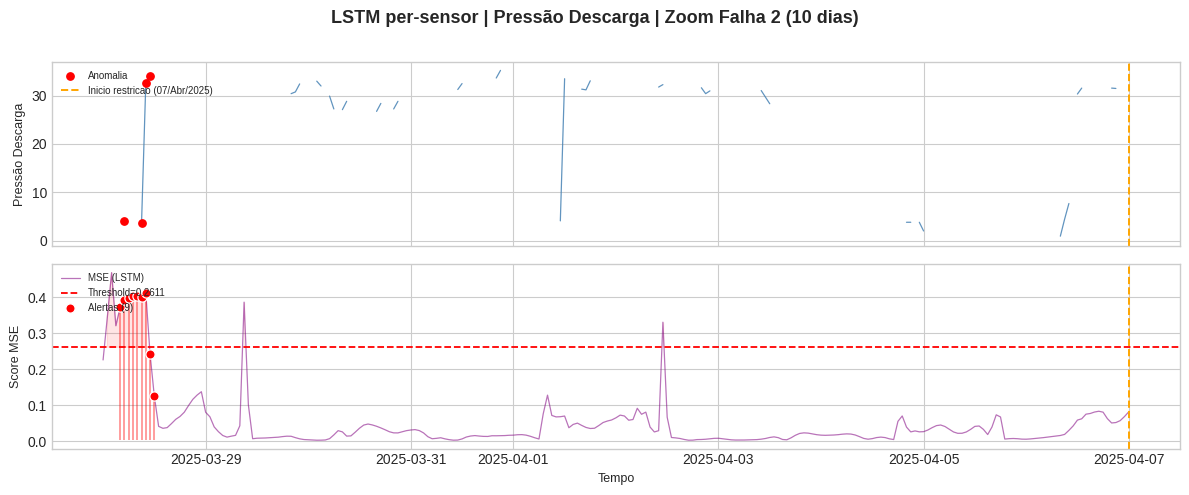


Sensor: Pressão Sucção | threshold=0.145349


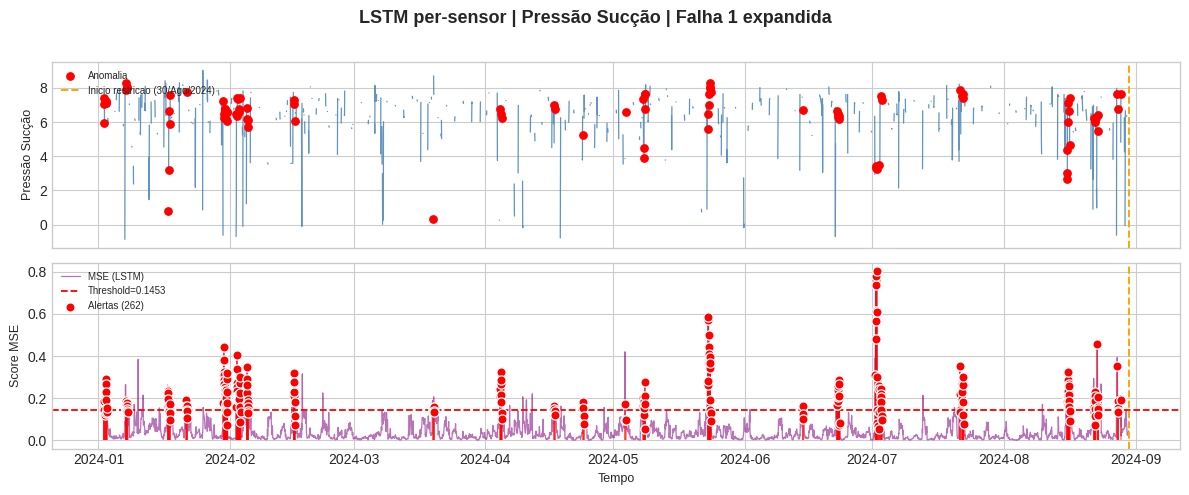

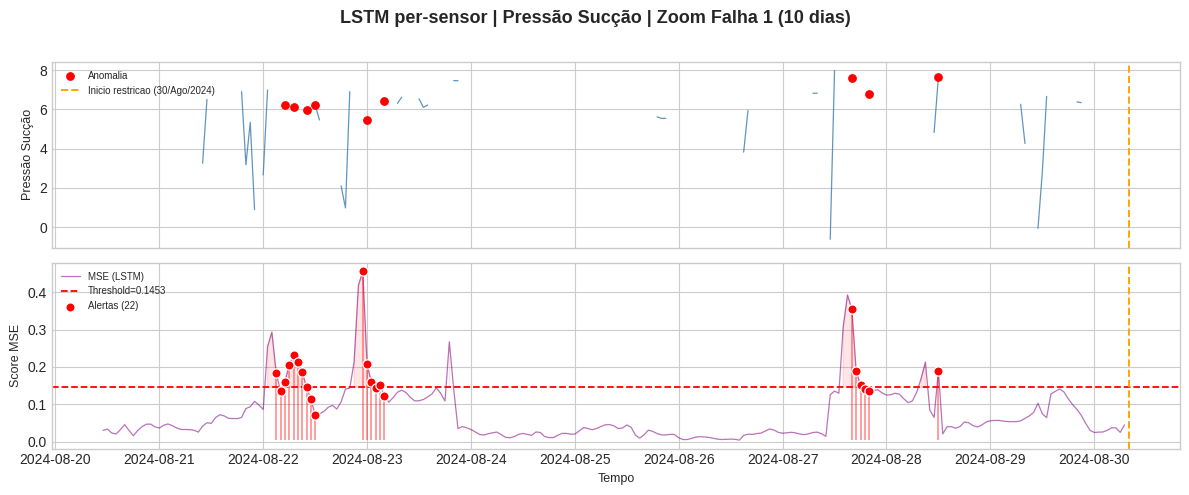

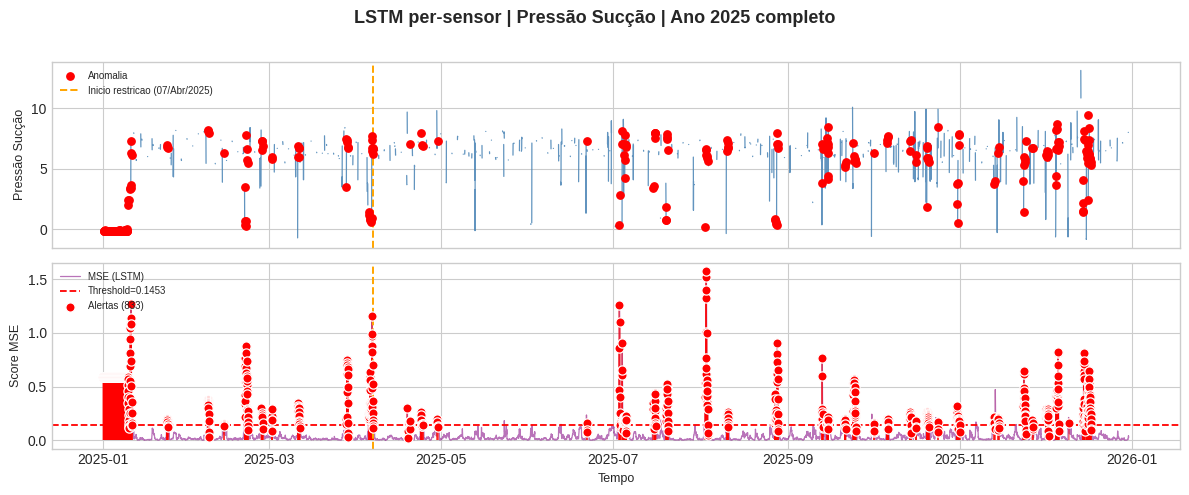

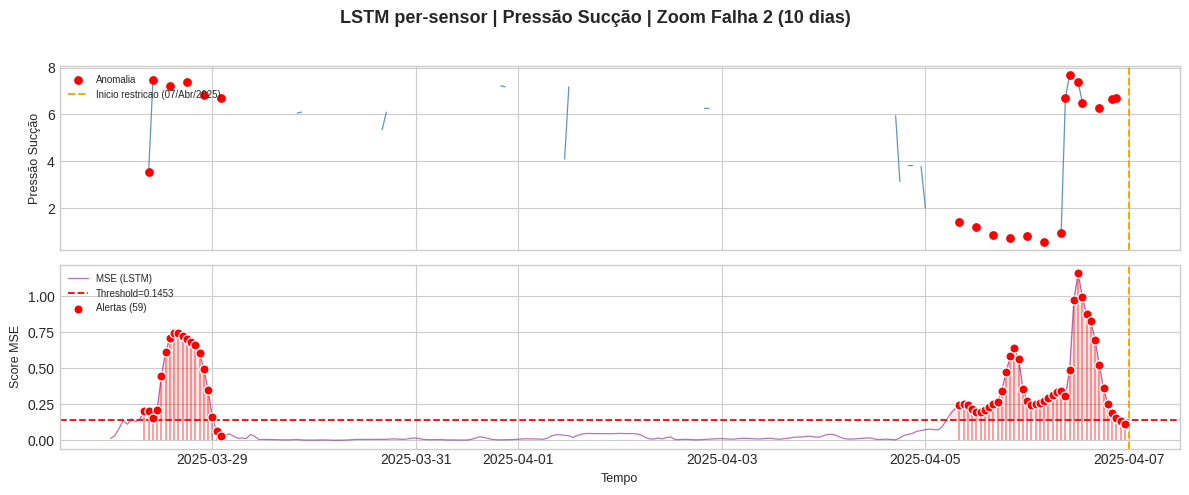


Sensor: Temperatura Bomba LA | threshold=0.021278


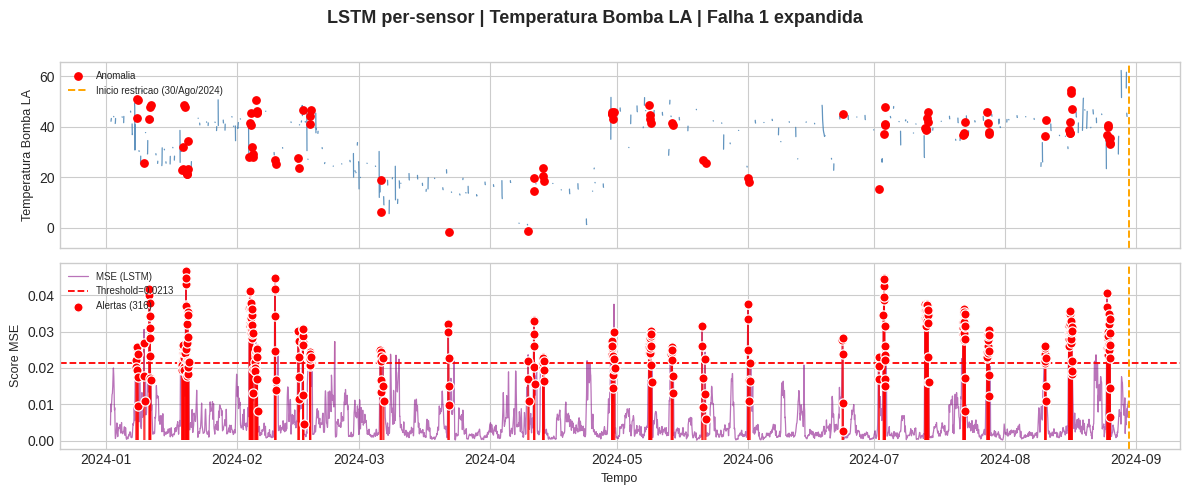

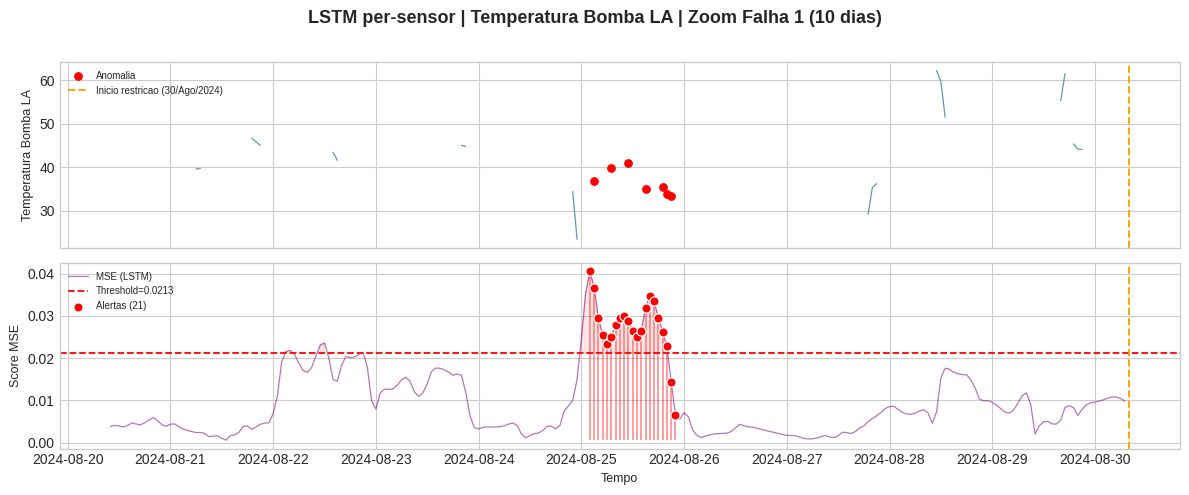

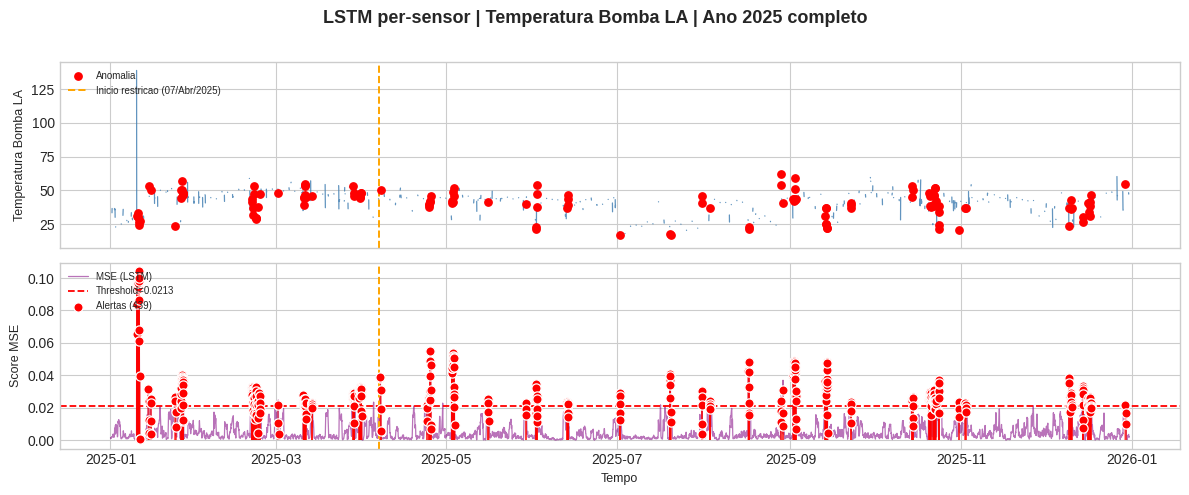

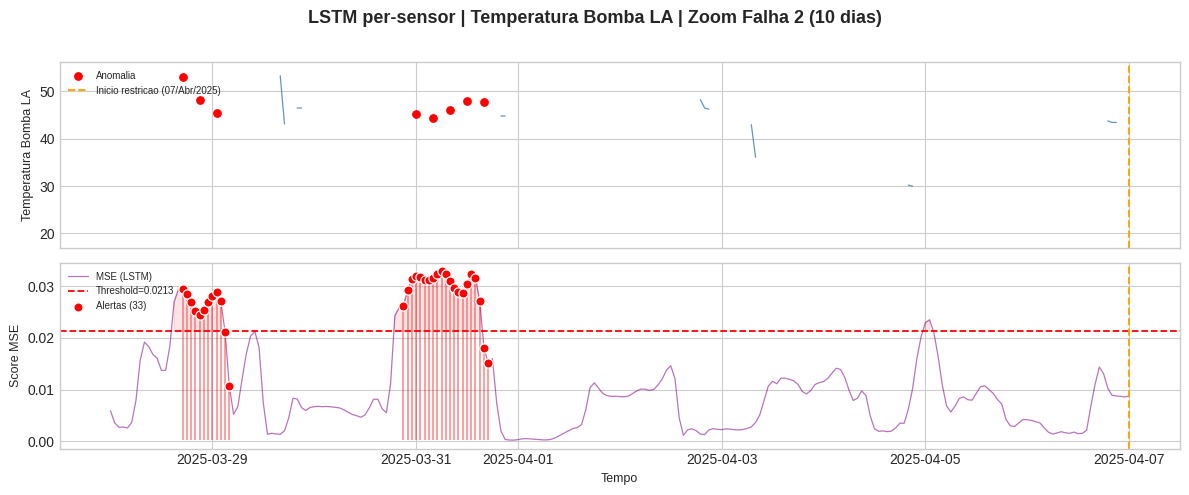


Sensor: Temperatura Bomba LNA | threshold=0.074985


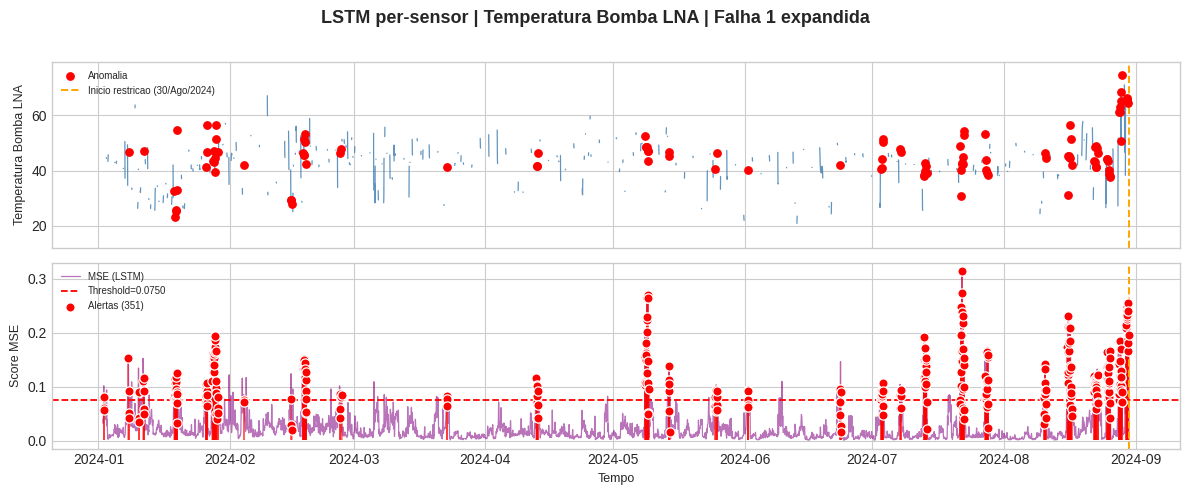

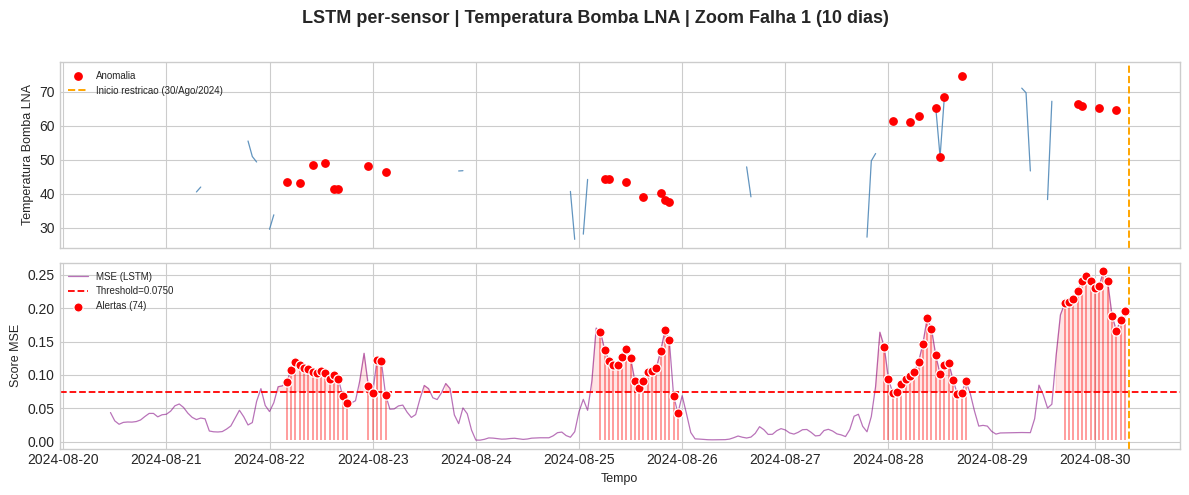

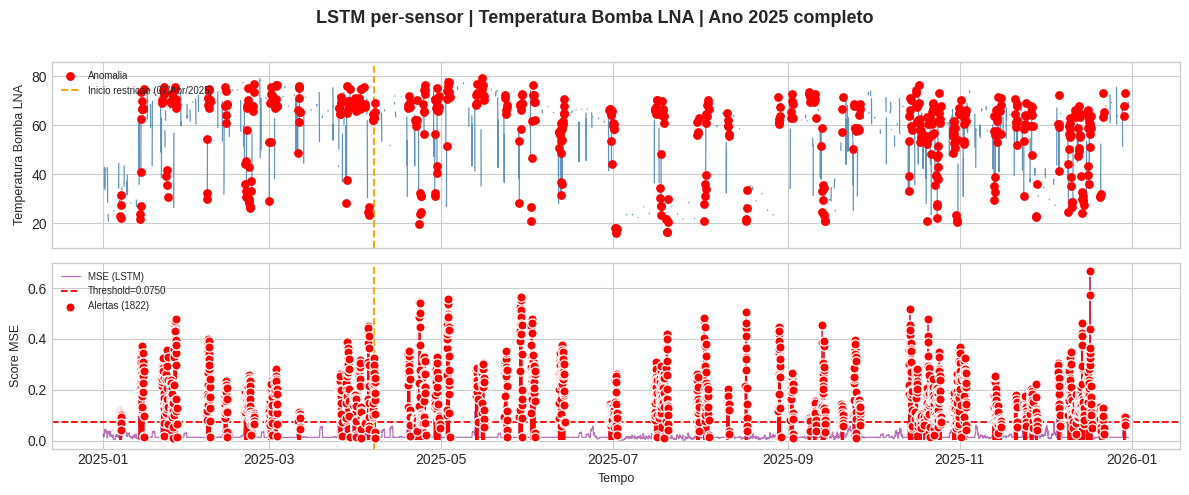

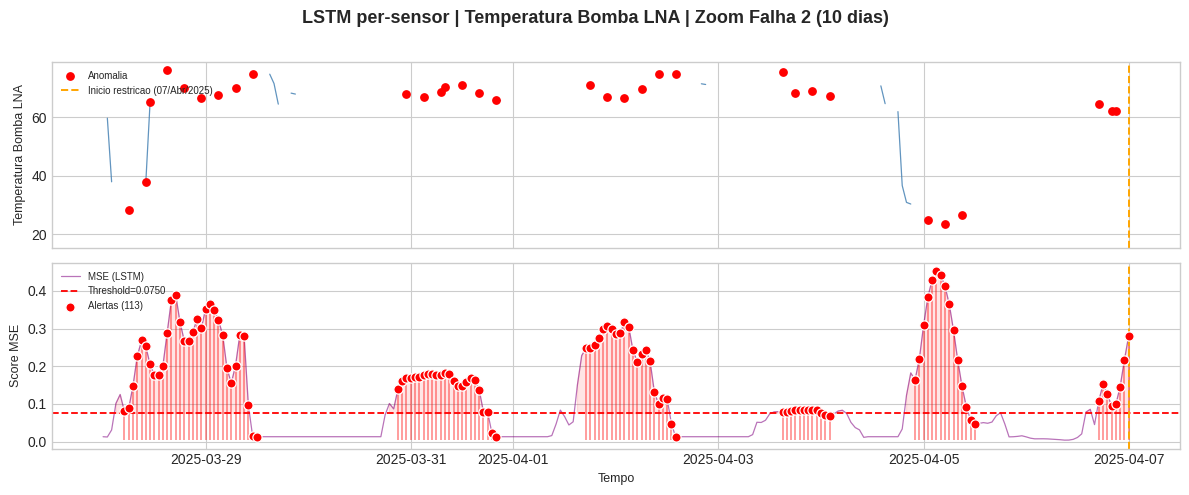


Sensor: Temperatura Motor LA | threshold=0.218627


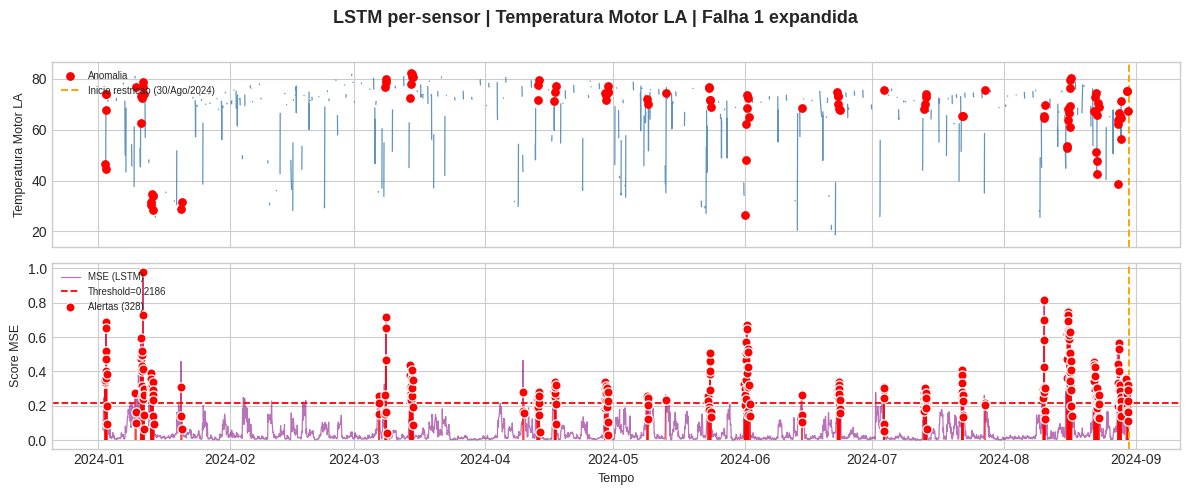

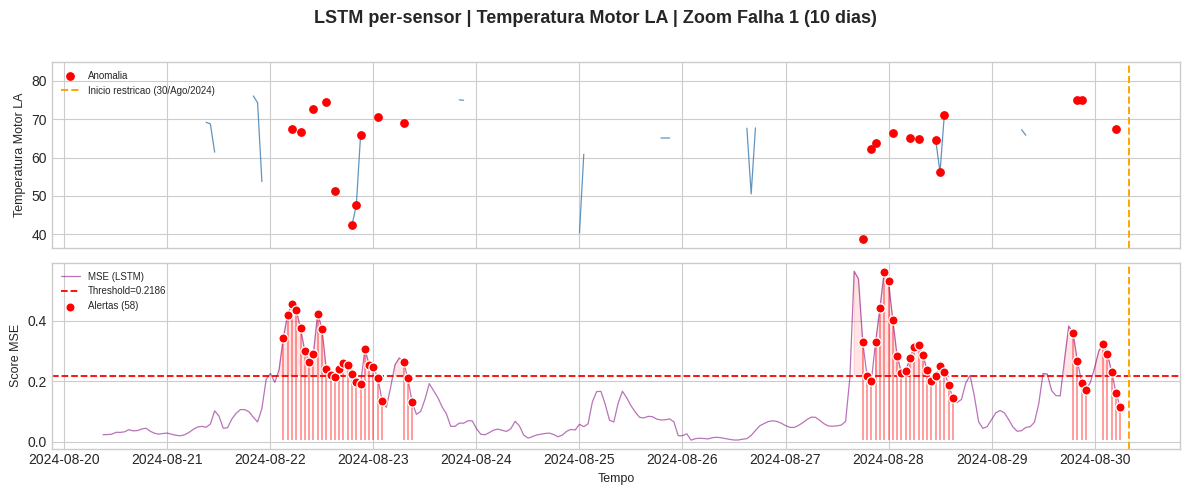

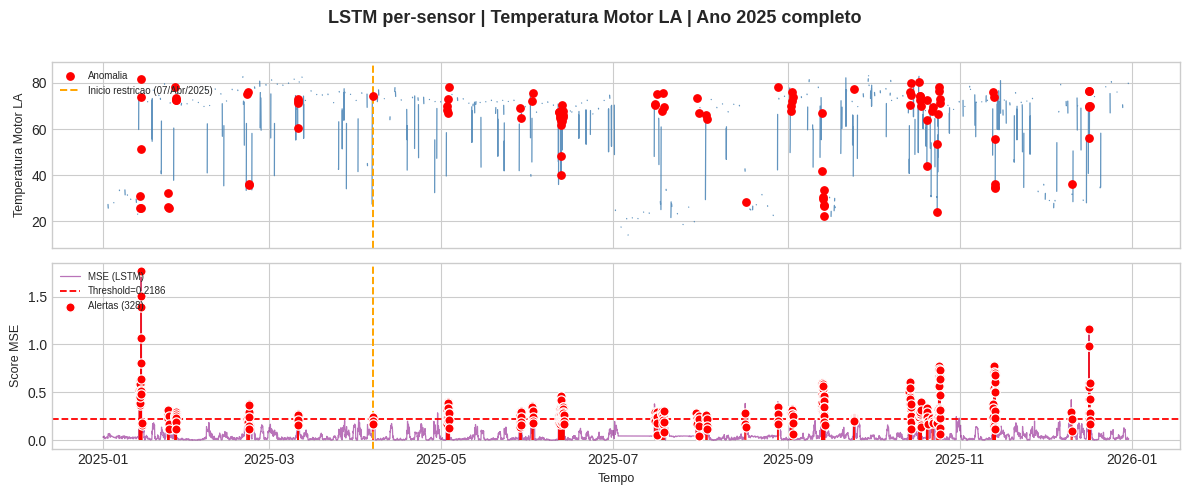

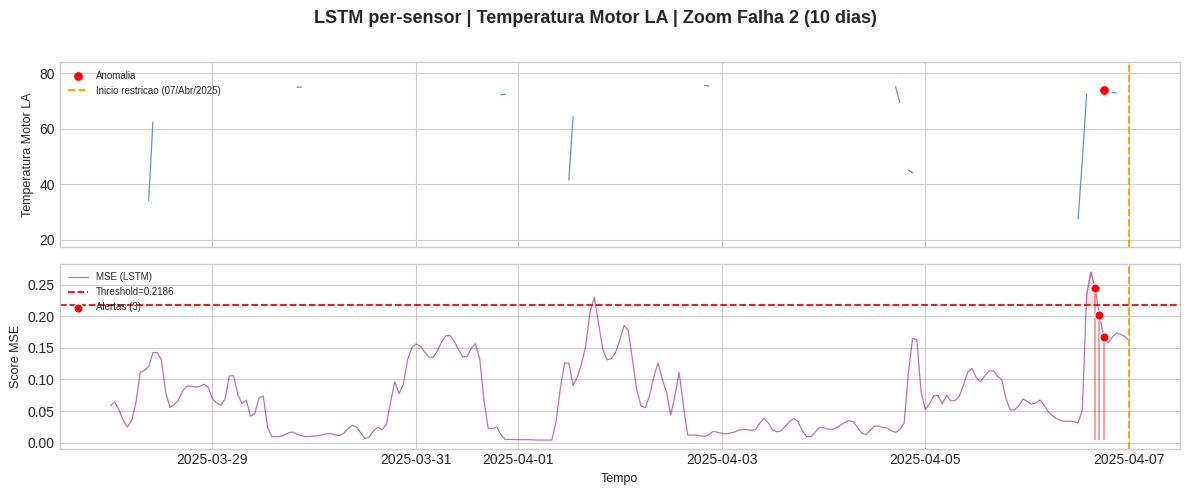


Sensor: Temperatura Motor LNA | threshold=0.180229


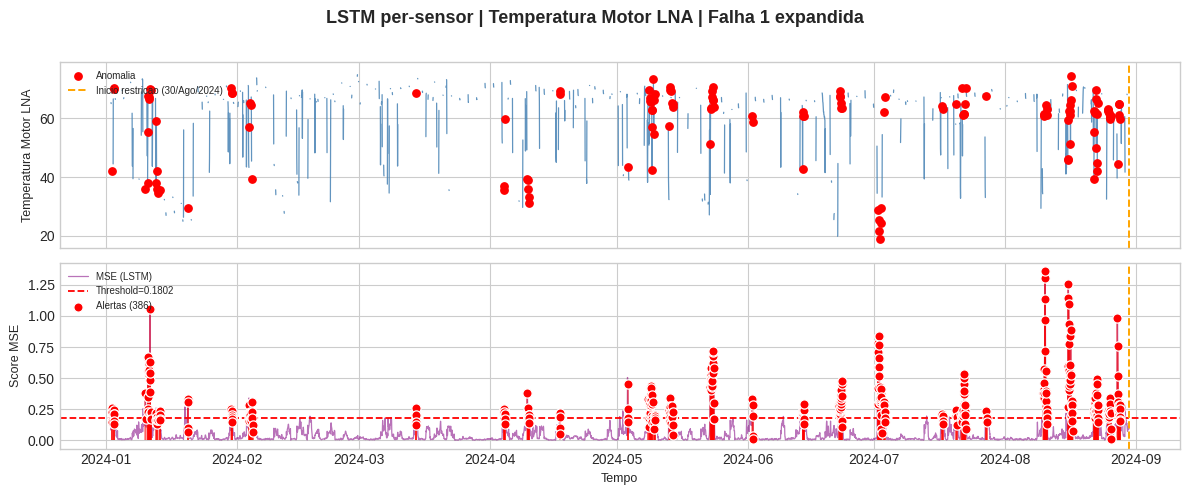

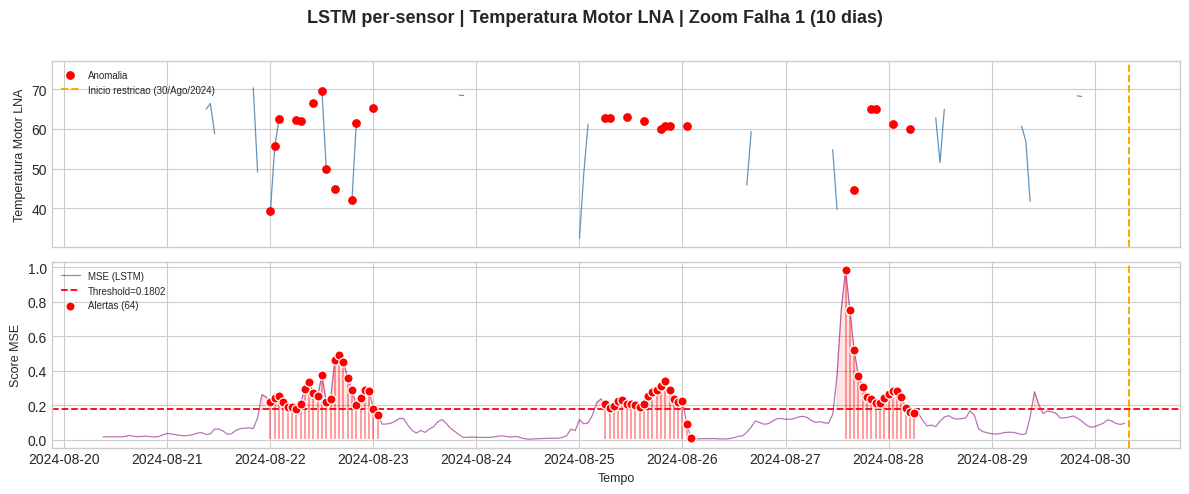

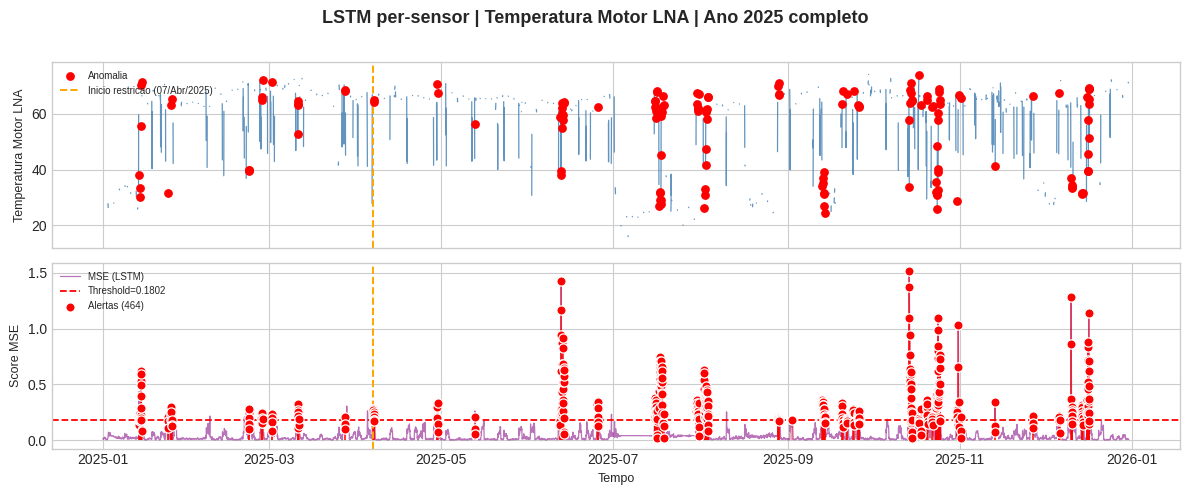

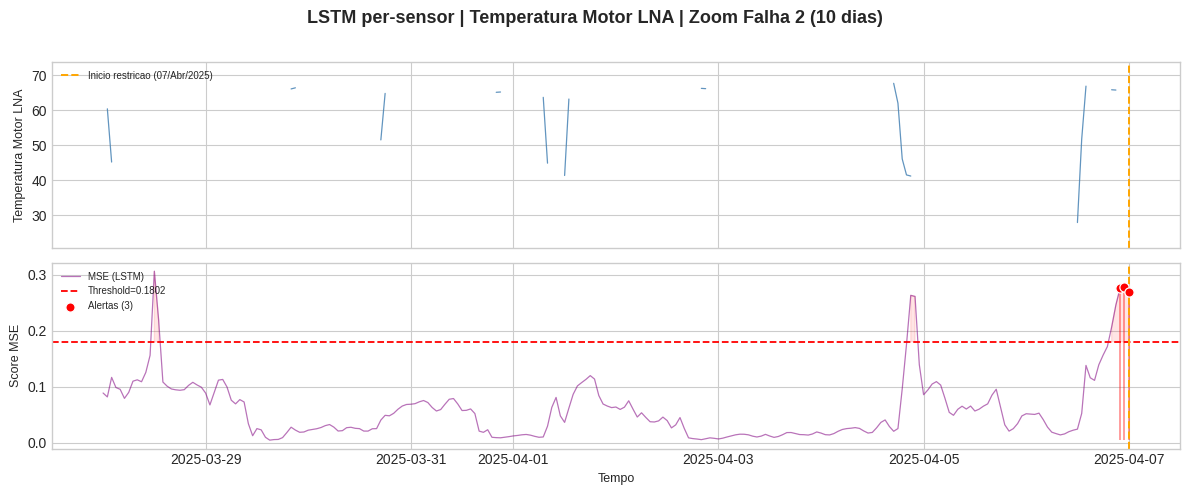


Sensor: Vibração Bomba LNA | threshold=0.094026


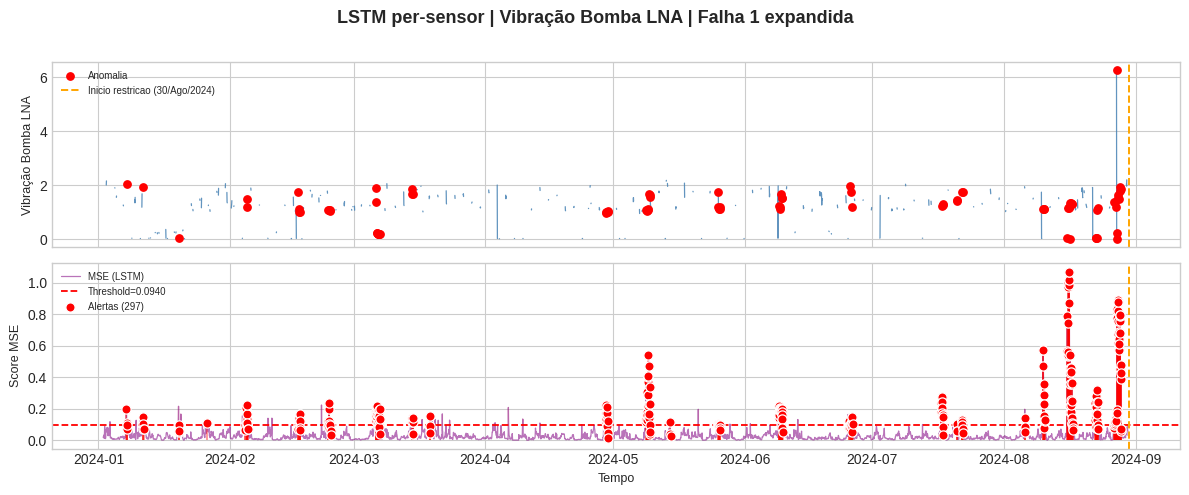

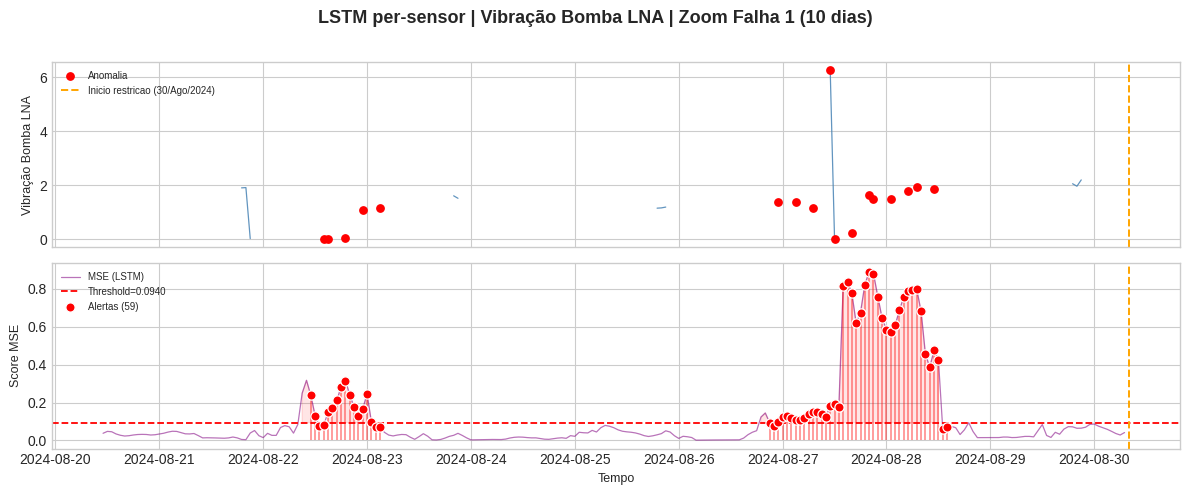

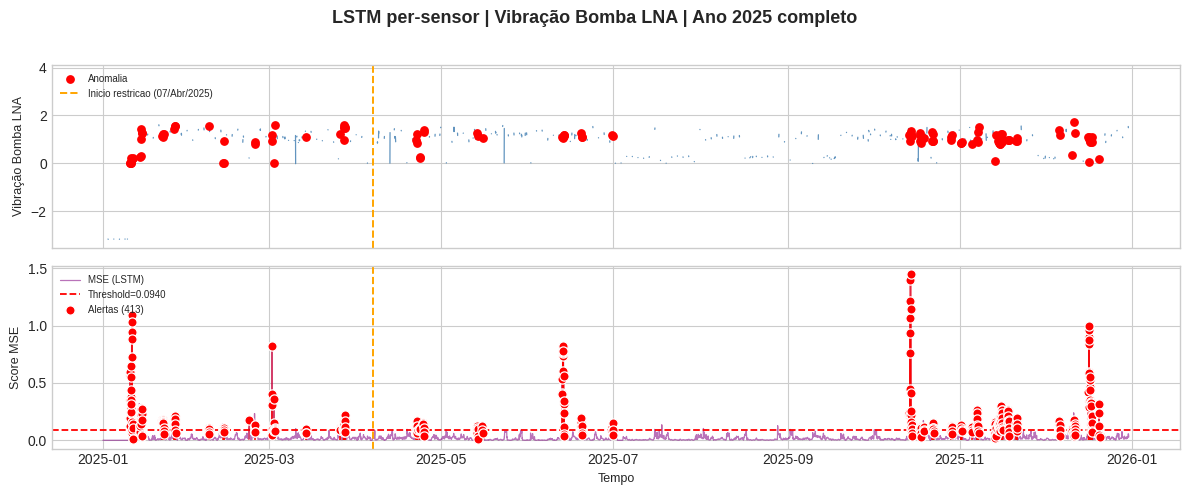

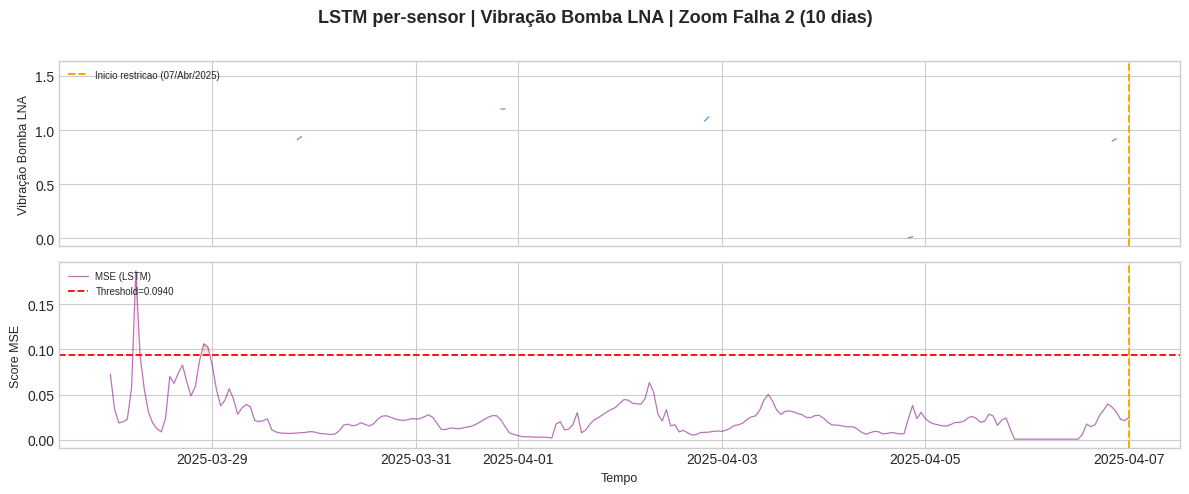


Resumo geral:


,sensor,janela,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Corrente,Falha 1 expandida,4867,183,3.76,0.078428,3,5
1,Corrente,Zoom Falha 1 (10 dias),206,8,3.88,0.078428,3,5
2,Corrente,Ano 2025 completo,6569,213,3.24,0.078428,3,5
3,Corrente,Zoom Falha 2 (10 dias),185,31,16.76,0.078428,3,5
4,Pressão Descarga,Falha 1 expandida,5761,267,4.63,0.261081,3,5
5,Pressão Descarga,Zoom Falha 1 (10 dias),238,30,12.61,0.261081,3,5
6,Pressão Descarga,Ano 2025 completo,8503,360,4.23,0.261081,3,5
7,Pressão Descarga,Zoom Falha 2 (10 dias),241,9,3.73,0.261081,3,5
8,Pressão Sucção,Falha 1 expandida,5786,262,4.53,0.145349,3,5
9,Pressão Sucção,Zoom Falha 1 (10 dias),237,22,9.28,0.145349,3,5


In [8]:
if PER_SENSOR_TASK_ID == 'PASTE_TASK_ID_HERE':
    raise ValueError('Defina PER_SENSOR_TASK_ID antes de executar.')

ps_task, sensor_entries, summary_df = load_per_sensor_task_outputs(PER_SENSOR_TASK_ID, USE_FULL_SCORES)

print(f'Task per-sensor: {ps_task.id}')
print(f'Sensores encontrados: {len(sensor_entries)}')
if not sensor_entries:
    raise RuntimeError('Task ainda sem artifacts per-sensor — aguarde a execucao terminar no servidor.')
if summary_df is not None:
    print('\nSummary:')
    display(summary_df)

df_base, config = load_plot_base(EQUIPMENT_ID)

# Calibracao de sensibilidade usando scores do primeiro sensor disponivel
first_slug = next(iter(sensor_entries))
first_scores = sensor_entries[first_slug]['scores']
sens = recommend_sensitivity(first_scores, CALIB_START, CALIB_END)
selected_k = sens['k']
selected_n = sens['n']
print(f'\nSensibilidade calibrada (baseada em {first_slug}): k={selected_k}, n={selected_n}, p={sens["percentile"]}')

windows = [
    {'name': 'Falha 1 expandida',     'start': first_scores.index.min(), 'end': EVENT_TS_F1,
     'event_date': EVENT_DATE_F1, 'event_label': EVENT_LABEL_F1},
    {'name': 'Zoom Falha 1 (10 dias)', 'start': WINDOW_F1_ZOOM_START,   'end': WINDOW_F1_ZOOM_END,
     'event_date': EVENT_DATE_F1, 'event_label': EVENT_LABEL_F1},
    {'name': 'Ano 2025 completo',       'start': WINDOW_2025_START,      'end': WINDOW_2025_END,
     'event_date': EVENT_DATE_F2, 'event_label': EVENT_LABEL_F2},
    {'name': 'Zoom Falha 2 (10 dias)', 'start': WINDOW_F2_ZOOM_START,   'end': WINDOW_F2_ZOOM_END,
     'event_date': EVENT_DATE_F2, 'event_label': EVENT_LABEL_F2},
]

summary_rows = []

for slug, entry in sensor_entries.items():
    sensor_name = entry['sensor']
    scores      = entry['scores']
    threshold   = entry['threshold']

    print(f'\n{"="*60}')
    print(f'Sensor: {sensor_name} | threshold={threshold:.6f}')

    # Seleciona coluna de sensor no df_base
    sensor_col = [c for c in df_base.columns if sensor_name.lower() in c.lower()]
    df_sensor  = df_base[sensor_col] if sensor_col else df_base.iloc[:, :1]

    for w in windows:
        try:
            df_w, scores_w = slice_window(df_sensor, scores, w['start'], w['end'])
        except ValueError:
            continue

        thr_flags  = scores_w['reconstruction_error'] > threshold
        anom_flags = persistence_filter(thr_flags, k=selected_k, n=selected_n)
        n_anom     = int(anom_flags.sum())
        n_samples  = len(scores_w)

        # Plot simples: sensor + score
        fig, axes = plt.subplots(2, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 2), sharex=True)
        plt.style.use('seaborn-v0_8-whitegrid')

        axes[0].plot(df_w.index, df_w.iloc[:, 0], color='steelblue', linewidth=0.9, alpha=0.85)
        anom_vals = df_w.iloc[:, 0].reindex(scores_w.index[anom_flags]).dropna()
        if not anom_vals.empty:
            axes[0].scatter(anom_vals.index, anom_vals.values, s=28, color='red', zorder=4, label='Anomalia')
        axes[0].axvline(pd.Timestamp(w['event_date']), color='orange', linestyle='--', linewidth=1.4, label=w['event_label'])
        axes[0].set_ylabel(sensor_name, fontsize=9)
        axes[0].legend(loc='upper left', fontsize=7)

        y = scores_w['reconstruction_error']
        axes[1].plot(scores_w.index, y, color='purple', linewidth=0.9, alpha=0.55, label='MSE (LSTM)')
        axes[1].axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=f'Threshold={threshold:.4f}')
        axes[1].fill_between(scores_w.index, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        if anom_flags.any():
            idx_p = scores_w.index[anom_flags]
            y_p   = scores_w.loc[idx_p, 'reconstruction_error']
            axes[1].vlines(idx_p, ymin=float(y.min()), ymax=y_p.values, color='red', alpha=0.45, linewidth=1.2)
            axes[1].scatter(idx_p, y_p, s=44, facecolor='red', edgecolor='white', linewidth=0.9, zorder=5, label=f'Alertas ({n_anom})')
        axes[1].axvline(pd.Timestamp(w['event_date']), color='orange', linestyle='--', linewidth=1.4)
        axes[1].set_ylabel('Score MSE', fontsize=9)
        axes[1].set_xlabel('Tempo', fontsize=9)
        axes[1].legend(loc='upper left', fontsize=7)

        title = f'LSTM per-sensor | {sensor_name} | {w["name"]}'
        fig.suptitle(title, fontsize=13, fontweight='bold')
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

        summary_rows.append({
            'sensor': sensor_name, 'janela': w['name'],
            'n_samples': n_samples, 'n_anomalies': n_anom,
            'pct_anomalies': round(100.0 * n_anom / n_samples, 2) if n_samples else 0.0,
            'threshold': threshold, 'k': selected_k, 'n': selected_n,
        })

print('\nResumo geral:')
display(pd.DataFrame(summary_rows))
